# X-Trend Context-Count Sweep

This notebook fixes the X-Trend hidden dimension and sweeps over the number of CPD contexts per episode. It reuses causal CPD caches and persists them to Google Drive so later notebooks can load the same regimes instead of recomputing them.


In [ ]:
# ── Check GPU ─────────────────────────────────────────────────────────────
import torch

if not torch.cuda.is_available():
    raise RuntimeError(
        "GPU not detected! Go to Runtime > Change runtime type > T4 GPU"
    )

print(f"PyTorch {torch.__version__} | GPU: {torch.cuda.get_device_name(0)}")


PyTorch 2.10.0+cu128 | GPU: NVIDIA A100-SXM4-40GB


In [ ]:
# ── Clone repository & install dependencies ──────────────────────────────
import os, sys

%cd /content
!rm -rf S11685_Final_Project
!git clone https://github.com/billliu-cmd/S11685_Final_Project.git
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

!pip install -q numpy pandas scipy yfinance tqdm matplotlib

sys.path.insert(0, "/content")
print()
!ls -la S11685_Final_Project/*.py


/content
Cloning into 'S11685_Final_Project'...
remote: Enumerating objects: 250, done.
remote: Counting objects: 100% (114/114), done.
remote: Compressing objects: 100% (106/106), done.
remote: Total 250 (delta 67), reused 8 (delta 8), pack-reused 136 (from 1)
Receiving objects: 100% (250/250), 1.09 MiB | 34.95 MiB/s, done.
Resolving deltas: 100% (131/131), done.

-rw-r--r-- 1 root root  4776 Apr 21 17:15 S11685_Final_Project/backtest.py
-rw-r--r-- 1 root root   986 Apr 21 17:15 S11685_Final_Project/Baseline.py
-rw-r--r-- 1 root root  8252 Apr 21 17:15 S11685_Final_Project/components.py
-rw-r--r-- 1 root root  2424 Apr 21 17:15 S11685_Final_Project/config.py
-rw-r--r-- 1 root root  9574 Apr 21 17:15 S11685_Final_Project/cpd.py
-rw-r--r-- 1 root root 33786 Apr 21 17:15 S11685_Final_Project/data2.py
-rw-r--r-- 1 root root 24388 Apr 21 17:15 S11685_Final_Project/data.py
-rw-r--r-- 1 root root     1 Apr 21 17:15 S11685_Final_Project/__init__.py
-rw-r--r-- 1 root root 16442 Apr 21 17:15 S1

In [ ]:
# ── Mount Google Drive & persistent caches ─────────────────────────────
from google.colab import drive
import os, shutil

drive.mount('/content/drive')

DRIVE_CPD_CACHE_DIR = '/content/drive/MyDrive/cpd_cache'
DRIVE_PANEL_CACHE_DIR = '/content/drive/MyDrive/panel_cache'
CPD_CACHE_DIR = DRIVE_CPD_CACHE_DIR

os.makedirs(DRIVE_CPD_CACHE_DIR, exist_ok=True)
os.makedirs(DRIVE_PANEL_CACHE_DIR, exist_ok=True)

PANEL_CACHE_TAG = 'etf21_default_auto_adjust_false_v1'
PANEL_BUNDLE_PATH = os.path.join(
    DRIVE_PANEL_CACHE_DIR,
    f'panel_bundle_{PANEL_CACHE_TAG}.pkl',
)
FORCE_REBUILD_PANEL = False

RUNTIME_CPD_CACHE_DIR = '/content/cpd_cache'
copied = 0
if os.path.isdir(RUNTIME_CPD_CACHE_DIR):
    for name in os.listdir(RUNTIME_CPD_CACHE_DIR):
        src = os.path.join(RUNTIME_CPD_CACHE_DIR, name)
        dst = os.path.join(DRIVE_CPD_CACHE_DIR, name)
        if os.path.isfile(src) and not os.path.exists(dst):
            shutil.copy2(src, dst)
            copied += 1
print(f'Synced {copied} CPD cache file(s) from runtime cache to Drive.')
print('Persistent CPD cache dir:', DRIVE_CPD_CACHE_DIR)
print('Persistent panel bundle path:', PANEL_BUNDLE_PATH)


Mounted at /content/drive
Synced 0 CPD cache file(s) from runtime cache to Drive.
Persistent CPD cache dir: /content/drive/MyDrive/cpd_cache
Persistent panel bundle path: /content/drive/MyDrive/panel_cache/panel_bundle_etf21_default_auto_adjust_false_v1.pkl


In [ ]:
# ── Import project modules ────────────────────────────────────────────────
from copy import deepcopy
from pathlib import Path
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from S11685_Final_Project.config import DATA, MODEL, TRAIN, CPD
from S11685_Final_Project.data import build_panel, time_split, build_episode_loaders
from S11685_Final_Project.cpd import segment_panel_cached, build_regime_cache_cached
from S11685_Final_Project.x_trend import XTrend
from S11685_Final_Project.train import fit, _xtrend_step, eval_epoch
from S11685_Final_Project.backtest import run_backtest, compare_equity, print_comparison, build_benchmarks

print("All modules imported successfully")


All modules imported successfully


In [ ]:
# ── Reproducibility & sweep configs ───────────────────────────────────────
import random

seed = DATA["seed"]
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
np.random.seed(seed)
random.seed(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DATA_RUN = deepcopy(DATA)
TRAIN_RUN = deepcopy(TRAIN)
MODEL_BASE = deepcopy(MODEL)

# Set this from the hidden-dimension sweep once you decide on the default.
FIXED_HIDDEN_DIM = 96

# Start with a moderate sweep around the default context count of 10.
CONTEXT_COUNTS = [5, 10, 15, 20]

# Optional faster smoke run before a full sweep:
# TRAIN_RUN.update({"epochs": 15, "patience": 5})

CPD_N_JOBS = min(10, os.cpu_count() or 1)
CPD_CACHE_DIR = globals().get("CPD_CACHE_DIR", globals().get("DRIVE_CPD_CACHE_DIR", "/content/drive/MyDrive/cpd_cache"))

print("Context-count sweep:", CONTEXT_COUNTS)
print(f"Fixed hidden_dim: {FIXED_HIDDEN_DIM}")
print(f"CPD workers: {CPD_N_JOBS}")
print(f"CPD cache dir: {CPD_CACHE_DIR}")


Context-count sweep: [5, 10, 15, 20]
Fixed hidden_dim: 96
CPD workers: 10
CPD cache dir: /content/drive/MyDrive/cpd_cache


In [ ]:
# ── Tuning mode overrides (keep same universe for cache reuse) ─────────
# Keep these settings aligned with your hidden-dim sweep if you want to reuse the same Drive cache.
DATA_RUN["tickers"] = [
    "SPY", "QQQ", "IWM", "VTI",
    "EFA", "EEM",
    "XLF", "XLE", "XLK", "XLI", "XLP", "XLV",
    "VNQ",
    "TLT", "IEF", "SHY", "LQD", "HYG",
    "GLD", "DBC", "UUP",
]

# Optional: shorten history for faster experimentation.
# DATA_RUN["start"] = "2010-01-01"

print("Tuning mode active")
print(f"  Number of tickers: {len(DATA_RUN['tickers'])}")
print(f"  Start date:        {DATA_RUN['start']}")
print(f"  Epochs:            {TRAIN_RUN['epochs']}")
print(f"  Patience:          {TRAIN_RUN['patience']}")


Tuning mode active
  Number of tickers: 21
  Start date:        2005-01-01
  Epochs:            30
  Patience:          10


In [ ]:
# ── Build data panel, split, and causal CPD artifacts once ─────────────────
import pickle

def save_panel_bundle(path, panel, fcols, tk2id, data_run):
    bundle = {
        'panel': panel.copy(),
        'fcols': list(fcols),
        'tk2id': dict(tk2id),
        'data_run': deepcopy(data_run),
    }
    with open(path, 'wb') as f:
        pickle.dump(bundle, f, protocol=pickle.HIGHEST_PROTOCOL)

def load_panel_bundle(path):
    with open(path, 'rb') as f:
        bundle = pickle.load(f)
    panel = bundle['panel'].copy()
    panel['date'] = pd.to_datetime(panel['date'])
    return panel, bundle['fcols'], bundle['tk2id'], bundle.get('data_run')

print('Loading frozen panel bundle or building it once ...')

if (not FORCE_REBUILD_PANEL) and os.path.exists(PANEL_BUNDLE_PATH):
    panel, fcols, tk2id, cached_data_run = load_panel_bundle(PANEL_BUNDLE_PATH)
    print(f'Loaded frozen panel bundle from: {PANEL_BUNDLE_PATH}')
    if cached_data_run is not None and cached_data_run != DATA_RUN:
        raise RuntimeError(
            'The saved panel bundle was built under a different DATA_RUN. '
            'If this change is intentional, bump PANEL_CACHE_TAG or set FORCE_REBUILD_PANEL=True once.'
        )
else:
    print('No frozen panel bundle found; building panel from Yahoo once ...')
    panel, fcols, tk2id = build_panel(DATA_RUN)
    save_panel_bundle(PANEL_BUNDLE_PATH, panel, fcols, tk2id, DATA_RUN)
    print(f'Built and saved frozen panel bundle to: {PANEL_BUNDLE_PATH}')

train_d, val_d, test_d = time_split(panel, DATA_RUN['train_frac'], DATA_RUN['val_frac'])

n_assets = len(tk2id)
n_feat = len(fcols)

print(f"\n{'='*55}")
print(f"  Assets:     {n_assets}   {list(tk2id.keys())}")
print(f"  Features:   {n_feat}    {fcols}")
print(f"  Date range: {panel['date'].min().date()} -> {panel['date'].max().date()}")
print(f"  Train: {len(train_d):,} days  |  Val: {len(val_d):,} days  |  Test: {len(test_d):,} days")
print(f"  CPD workers: {CPD_N_JOBS}  |  cache dir: {CPD_CACHE_DIR}")
print(f"{'='*55}")

train_hist_end = train_d.max()
val_hist_end = val_d.max()
test_hist_end = test_d.max()

train_panel = panel[panel['date'] <= train_hist_end].copy()
val_panel_hist = panel[panel['date'] <= val_hist_end].copy()
test_panel_hist = panel[panel['date'] <= test_hist_end].copy()

print('\nBuilding causal CPD regimes/cache ...')
train_regimes = segment_panel_cached(
    train_panel,
    cache_dir=CPD_CACHE_DIR,
    n_jobs=CPD_N_JOBS,
)
val_regime_cache = build_regime_cache_cached(
    val_panel_hist,
    val_d,
    recompute_every=CPD['recompute_every'],
    cache_dir=CPD_CACHE_DIR,
    n_jobs=CPD_N_JOBS,
)
test_regime_cache = build_regime_cache_cached(
    test_panel_hist,
    test_d,
    recompute_every=CPD['recompute_every'],
    cache_dir=CPD_CACHE_DIR,
    n_jobs=CPD_N_JOBS,
)

train_regime_lengths = [re - rs + 1 for rs_re in train_regimes.values() for rs, re in rs_re]
print(f"Train contexts discovered: {len(train_regime_lengths):,}")
if train_regime_lengths:
    print(
        f"Train regime length stats -> min: {min(train_regime_lengths)}, "
        f"median: {int(np.median(train_regime_lengths))}, "
        f"max: {max(train_regime_lengths)}"
    )

print(f"Val cache snapshots:  {len(val_regime_cache)}")
print(f"Test cache snapshots: {len(test_regime_cache)}")

_, loaders = build_episode_loaders(
    panel, fcols, train_d, val_d, test_d,
    train_regimes,
    DATA_RUN,
    regime_caches={'val': val_regime_cache, 'test': test_regime_cache},
)

print(f"\nTrain batches: {len(loaders['train'])}")
print(f"Val   batches: {len(loaders['val'])}")
print(f"Test  batches: {len(loaders['test'])}")


Loading frozen panel bundle or building it once ...
No frozen panel bundle found; building panel from Yahoo once ...
Built and saved frozen panel bundle to: /content/drive/MyDrive/panel_cache/panel_bundle_etf21_default_auto_adjust_false_v1.pkl

  Assets:     21   ['DBC', 'EEM', 'EFA', 'GLD', 'HYG', 'IEF', 'IWM', 'LQD', 'QQQ', 'SHY', 'SPY', 'TLT', 'UUP', 'VNQ', 'VTI', 'XLE', 'XLF', 'XLI', 'XLK', 'XLP', 'XLV']
  Features:   8    ['norm_ret_1', 'norm_ret_21', 'norm_ret_63', 'norm_ret_126', 'norm_ret_252', 'macd_8_24', 'macd_16_28', 'macd_32_96']
  Date range: 2007-04-11 -> 2025-12-29
  Train: 3,297 days  |  Val: 707 days  |  Test: 707 days
  CPD workers: 10  |  cache dir: /content/drive/MyDrive/cpd_cache

Building causal CPD regimes/cache ...
Loading cached train regimes from /content/drive/MyDrive/cpd_cache/regimes_ada0bea2c38ef1bf.pkl
Loading cached regime snapshots from /content/drive/MyDrive/cpd_cache/regime_cache_c433d3156bbf6661.pkl
Loading cached regime snapshots from /content/driv

In [ ]:
# -- Sync freshly built CPD cache to Google Drive -------------------------
import os, shutil

copied = 0
if CPD_CACHE_DIR != DRIVE_CPD_CACHE_DIR and os.path.isdir(CPD_CACHE_DIR):
    for name in os.listdir(CPD_CACHE_DIR):
        src = os.path.join(CPD_CACHE_DIR, name)
        dst = os.path.join(DRIVE_CPD_CACHE_DIR, name)
        if os.path.isfile(src):
            shutil.copy2(src, dst)
            copied += 1

files = sorted(os.listdir(DRIVE_CPD_CACHE_DIR)) if os.path.isdir(DRIVE_CPD_CACHE_DIR) else []
print(f'Synced {copied} CPD cache file(s) to Google Drive after CPD build.')
print('Drive CPD cache dir:', DRIVE_CPD_CACHE_DIR)
print('Files now available in Drive:')
for name in files:
    print(' ', name)


Synced 0 CPD cache file(s) to Google Drive after CPD build.
Drive CPD cache dir: /content/drive/MyDrive/cpd_cache
Files now available in Drive:
  regime_cache_3a0edd0de03df534.pkl
  regime_cache_c433d3156bbf6661.pkl
  regime_cache_d309ae9d4e1754dc.pkl
  regime_cache_ef0895950a14e489.pkl
  regimes_ada0bea2c38ef1bf.pkl
  regimes_d324722929419fb4.pkl


In [ ]:
CONTEXT_COUNTS = [12, 15, 20, 25, 30]

In [ ]:
# ── Helper: train one context-count configuration ────────────────────────
device = "cuda"

def train_one_context_count(num_context):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)

    torch.cuda.empty_cache()

    data_cfg = deepcopy(DATA_RUN)
    data_cfg["num_context"] = num_context
    model_cfg = deepcopy(MODEL_BASE)
    model_cfg["hidden_dim"] = FIXED_HIDDEN_DIM

    _, loaders = build_episode_loaders(
        panel, fcols, train_d, val_d, test_d,
        train_regimes,
        data_cfg,
        regime_caches={"val": val_regime_cache, "test": test_regime_cache},
    )

    model = XTrend(n_feat, n_assets, model_cfg).to(device)
    params_total = sum(p.numel() for p in model.parameters())
    params_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

    print(f"\n{'='*70}")
    print(f"Training X-Trend with num_context = {num_context}")
    print(f"  Fixed hidden_dim: {FIXED_HIDDEN_DIM}")
    print(f"  Parameters:       {params_total:,}  ({params_trainable:,} trainable)")
    print(f"  Train batches:    {len(loaders['train'])}  (batch_size={data_cfg['batch_size']})")
    print(f"{'='*70}")

    start = time.perf_counter()
    model, history = fit(
        model,
        loaders["train"],
        loaders["val"],
        device,
        _xtrend_step,
        TRAIN_RUN,
        model_cfg,
    )
    elapsed = time.perf_counter() - start

    test_results = eval_epoch(
        model,
        loaders["test"],
        device,
        model_cfg["warmup_steps"],
        _xtrend_step,
    )

    pred_df = test_results["pred_df"]
    backtest = run_backtest(pred_df, cost_bps=TRAIN_RUN["cost_bps"], label=f"X-Trend C={num_context}")
    best_idx = history["val_sharpe"].idxmax()
    best = history.loc[best_idx]

    summary = {
        "num_context": num_context,
        "hidden_dim": FIXED_HIDDEN_DIM,
        "params_total": params_total,
        "params_trainable": params_trainable,
        "train_seconds": elapsed,
        "best_epoch": int(best["epoch"]),
        "best_val_sharpe": float(best["val_sharpe"]),
        "best_val_sharpe_gross": float(best.get("val_sharpe_gross", np.nan)),
        "best_val_sharpe_net": float(best.get("val_sharpe_net", best["val_sharpe"])),
        "best_val_mdd": float(best["val_mdd"]),
        "best_val_mdd_gross": float(best.get("val_mdd_gross", np.nan)),
        "best_val_mdd_net": float(best.get("val_mdd_net", best["val_mdd"])),
        "val_turnover": float(best.get("val_turnover", np.nan)),
        "test_loss": float(test_results["loss"]),
        "test_gross_sharpe": float(test_results.get("gross_sharpe", test_results["sharpe"])),
        "test_net_sharpe": float(test_results["net_sharpe"]),
        "test_gross_mdd": float(test_results.get("gross_max_drawdown", test_results["max_drawdown"])),
        "test_net_mdd": float(test_results["net_max_drawdown"]),
        "gross_ann_return": float(backtest["gross"]["ann_return"]),
        "gross_ann_vol": float(backtest["gross"]["ann_vol"]),
        "gross_sharpe": float(backtest["gross"]["sharpe"]),
        "net_ann_return": float(backtest["net"]["ann_return"]),
        "net_ann_vol": float(backtest["net"]["ann_vol"]),
        "net_sharpe": float(backtest["net"]["sharpe"]),
        "backtest_net_sharpe": float(backtest["net"]["sharpe"]),
        "avg_turnover": float(backtest["turnover"].mean()),
        "pred_rows": int(len(pred_df)),
    }

    print(f"Best val Net Sharpe:  {summary['best_val_sharpe']:.4f} @ epoch {summary['best_epoch']}")
    print(f"Test Gross Sharpe:    {summary['test_gross_sharpe']:.4f}")
    print(f"Test Net Sharpe:      {summary['test_net_sharpe']:.4f}")
    print(f"Backtest Net Sharpe:  {summary['net_sharpe']:.4f}")
    print(f"Train seconds:   {summary['train_seconds']:.1f}")

    state_dict = {k: v.detach().cpu() for k, v in model.state_dict().items()}
    del model
    torch.cuda.empty_cache()

    return {
        "state_dict": state_dict,
        "data_cfg": data_cfg,
        "model_cfg": model_cfg,
        "history": history,
        "test_results": test_results,
        "backtest": backtest,
        "summary": summary,
    }


In [ ]:
%%time
# ── Run sweep ─────────────────────────────────────────────────────────────
sweep_results = {}
for num_context in CONTEXT_COUNTS:
    sweep_results[num_context] = train_one_context_count(num_context)

summary_df = pd.DataFrame([sweep_results[c]["summary"] for c in CONTEXT_COUNTS])
summary_df = summary_df.sort_values("num_context").reset_index(drop=True)
summary_df


train: kept 65,996/65,996 targets (0 dropped for no causal contexts)
val: kept 14,847/14,847 targets (0 dropped for no causal contexts)
  avg causal context pool per target date: 3584.7
test: kept 14,847/14,847 targets (0 dropped for no causal contexts)
  avg causal context pool per target date: 4290.8

Training X-Trend with num_context = 12
  Fixed hidden_dim: 96
  Parameters:       1,051,426  (1,051,426 trainable)
  Train batches:    1032  (batch_size=64)


train:   0%|          | 0/1032 [00:00<?, ?it/s]

eval:   0%|          | 0/232 [00:00<?, ?it/s]

Ep 001 | trn 0.2954 | val -0.0723 | gross -0.0536 | net -0.0588 | to 0.0029 | lr 9.97e-04


train:   0%|          | 0/1032 [00:00<?, ?it/s]

...

eval:   0%|          | 0/232 [00:00<?, ?it/s]

Ep 011 | trn -0.8558 | val -0.2163 | gross 0.2896 | net 0.0667 | to 0.1337 | lr 7.03e-04
Early stop at epoch 11


eval:   0%|          | 0/232 [00:00<?, ?it/s]

Best val Net Sharpe:  0.2281 @ epoch 2
Test Gross Sharpe:    0.9575
Test Net Sharpe:      0.9555
Backtest Net Sharpe:  0.9555
Train seconds:   1070.9
CPU times: user 2h 11min 21s, sys: 17.7 s, total: 2h 11min 38s
Wall time: 1h 34min 36s


,num_context,hidden_dim,params_total,params_trainable,train_seconds,best_epoch,best_val_sharpe,best_val_sharpe_gross,best_val_sharpe_net,best_val_mdd,...,test_net_mdd,gross_ann_return,gross_ann_vol,gross_sharpe,net_ann_return,net_ann_vol,net_sharpe,backtest_net_sharpe,avg_turnover,pred_rows
0,12,96,1051426,1051426,854.147350,1,-0.058782,-0.053571,-0.058782,-0.151538,...,-0.086603,0.075880,0.072931,1.039480,0.075481,0.072932,1.034375,1.034375,0.002941,14847
1,15,96,1051426,1051426,957.688020,2,0.070579,0.073464,0.070579,-0.123951,...,-0.072870,0.073911,0.063013,1.163314,0.073720,0.063013,1.160479,1.160479,0.001417,14847
2,20,96,1051426,1051426,1106.163835,3,0.239481,0.392019,0.239481,-0.170143,...,-0.100393,0.093588,0.086300,1.080036,0.082441,0.086236,0.961925,0.961925,0.081386,14847
3,25,96,1051426,1051426,1536.150718,7,0.863899,1.770193,0.863899,-0.018197,...,-0.026537,0.006674,0.009976,0.671762,-0.002842,0.009972,-0.280377,-0.280377,0.075377,14847
4,30,96,1051426,1051426,1070.852482,2,0.228136,0.230151,0.228136,-0.171688,...,-0.101900,0.084854,0.089231,0.957544,0.084657,0.089232,0.955495,0.955495,0.001442,14847


In [ ]:
# ── Sweep summary table ───────────────────────────────────────────────────
display_cols = [
    "num_context", "hidden_dim", "params_total", "train_seconds", "best_epoch",
    "best_val_sharpe", "best_val_sharpe_gross", "best_val_mdd", "test_gross_sharpe", "test_net_sharpe", "net_sharpe", "avg_turnover",
]
display(summary_df[display_cols].style.format({
    "params_total": "{:,.0f}",
    "train_seconds": "{:.1f}",
    "best_val_sharpe": "{:.4f}",
    "best_val_mdd": "{:.4f}",
    "test_gross_sharpe": "{:.4f}",
    "test_net_sharpe": "{:.4f}",
    "net_sharpe": "{:.4f}",
    "avg_turnover": "{:.4f}",
}))

best_context = int(summary_df.loc[summary_df["best_val_sharpe"].idxmax(), "num_context"])
print(f"Recommended by validation net Sharpe: num_context = {best_context}")


,num_context,hidden_dim,params_total,train_seconds,best_epoch,best_val_sharpe,best_val_sharpe_gross,best_val_mdd,test_gross_sharpe,test_net_sharpe,net_sharpe,avg_turnover
0,12,96,"1,051,426",854.1,1,-0.0588,-0.053571,-0.1515,1.0395,1.0344,1.0344,0.0029
1,15,96,"1,051,426",957.7,2,0.0706,0.073464,-0.1240,1.1633,1.1605,1.1605,0.0014
2,20,96,"1,051,426",1106.2,3,0.2395,0.392019,-0.1701,1.0800,0.9619,0.9619,0.0814
3,25,96,"1,051,426",1536.2,7,0.8639,1.770193,-0.0182,0.6718,-0.2804,-0.2804,0.0754
4,30,96,"1,051,426",1070.9,2,0.2281,0.230151,-0.1717,0.9575,0.9555,0.9555,0.0014


Recommended by validation net Sharpe: num_context = 25


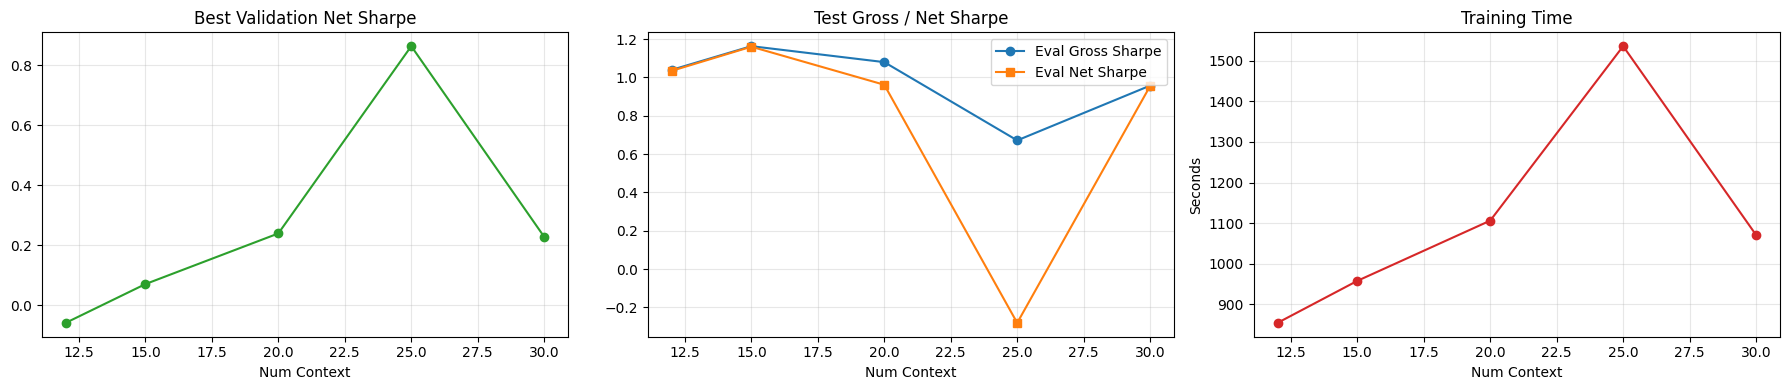

In [ ]:
# ── Cross-run comparison plots ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(summary_df["num_context"], summary_df["best_val_sharpe"], marker="o", color="tab:green")
axes[0].set_title("Best Validation Net Sharpe")
axes[0].set_xlabel("Num Context")
axes[0].grid(alpha=0.3)

axes[1].plot(summary_df["num_context"], summary_df["test_gross_sharpe"], marker="o", color="tab:blue", label="Eval Gross Sharpe")
axes[1].plot(summary_df["num_context"], summary_df["test_net_sharpe"], marker="s", color="tab:orange", label="Eval Net Sharpe")
axes[1].set_title("Test Gross / Net Sharpe")
axes[1].set_xlabel("Num Context")
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].plot(summary_df["num_context"], summary_df["train_seconds"], marker="o", color="tab:red")
axes[2].set_title("Training Time")
axes[2].set_xlabel("Num Context")
axes[2].set_ylabel("Seconds")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()


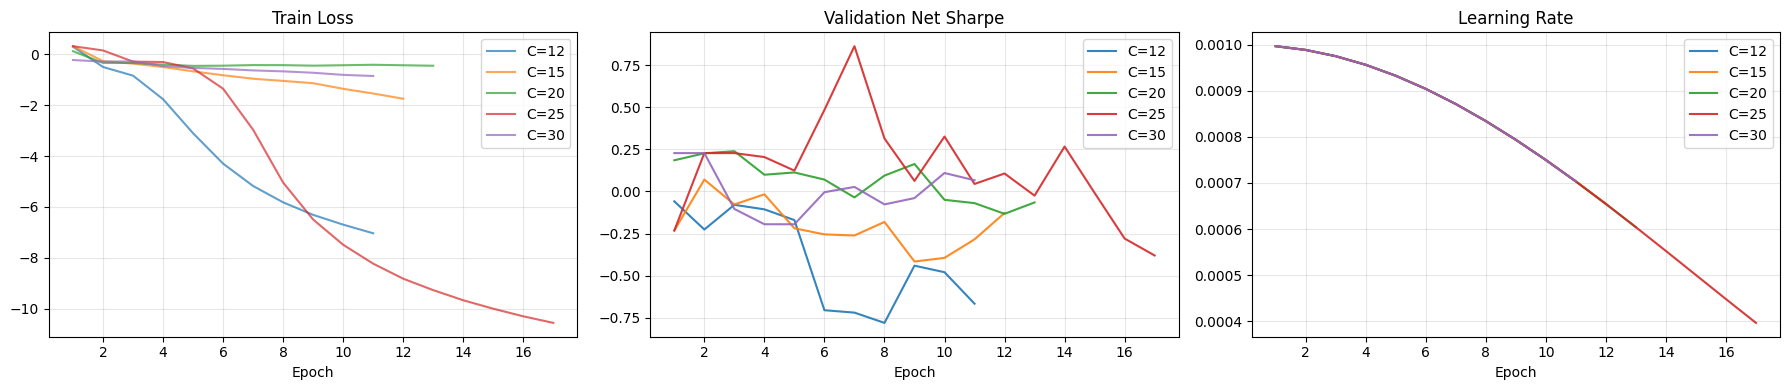

In [ ]:
# ── Training curves by context count ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for num_context in CONTEXT_COUNTS:
    hist = sweep_results[num_context]["history"]
    axes[0].plot(hist["epoch"], hist["train_loss"], alpha=0.7, label=f"C={num_context}")
    axes[1].plot(hist["epoch"], hist["val_sharpe"], alpha=0.9, label=f"C={num_context}")
    axes[2].plot(hist["epoch"], hist["lr"], alpha=0.9, label=f"C={num_context}")

axes[0].set_title("Train Loss")
axes[0].set_xlabel("Epoch")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].set_title("Validation Net Sharpe")
axes[1].set_xlabel("Epoch")
axes[1].grid(alpha=0.3)
axes[1].legend()

axes[2].set_title("Learning Rate")
axes[2].set_xlabel("Epoch")
axes[2].grid(alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.show()


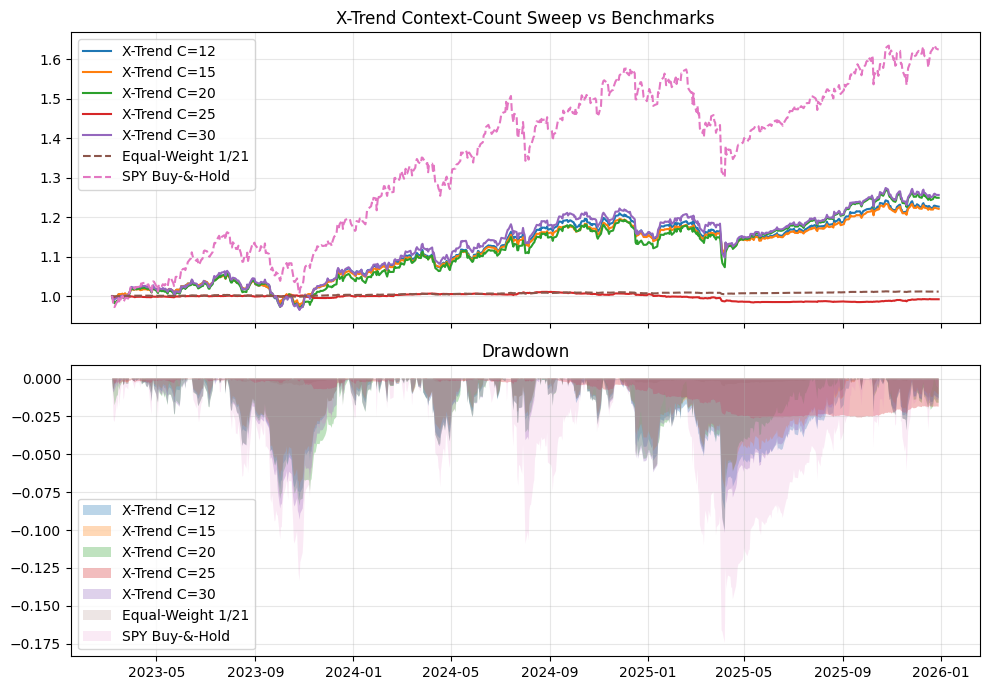

                   gross_ann_return  gross_ann_vol  gross_sharpe  gross_max_dd  gross_calmar  gross_hit_rate  gross_days  net_ann_return  net_ann_vol  net_sharpe  net_max_dd  net_calmar  net_hit_rate  net_days  avg_turnover
model                                                                                                                                                                                                                          
X-Trend C=12                 0.0759         0.0729        1.0395       -0.0866        0.8767          0.5474         707          0.0755       0.0729      1.0344     -0.0866      0.8716        0.5474       707        0.0029
X-Trend C=15                 0.0739         0.0630        1.1633       -0.0729        1.0143          0.5431         707          0.0737       0.0630      1.1605     -0.0729      1.0117        0.5431       707        0.0014
X-Trend C=20                 0.0936         0.0863        1.0800       -0.0968        0.9666          0.

In [ ]:
# ── Equity curves vs benchmarks ───────────────────────────────────────────
best_run = sweep_results[best_context]
bench = build_benchmarks(best_run["test_results"]["pred_df"])
model_results = [sweep_results[c]["backtest"] for c in CONTEXT_COUNTS]
fig = compare_equity(model_results, bench, title="X-Trend Context-Count Sweep vs Benchmarks")
plt.show()

comparison_df = print_comparison(model_results + bench)


In [ ]:
# ── Save sweep outputs ────────────────────────────────────────────────────
OUT = Path("/content/results_xtrend_context_count_sweep")
OUT.mkdir(parents=True, exist_ok=True)

summary_df.to_csv(OUT / "context_count_summary.csv", index=False)
comparison_df.to_csv(OUT / "comparison_table.csv")

for num_context in CONTEXT_COUNTS:
    run = sweep_results[num_context]
    torch.save(run["state_dict"], OUT / f"xtrend_c{num_context}.pt")
    run["history"].to_csv(OUT / f"xtrend_c{num_context}_history.csv", index=False)
    run["test_results"]["pred_df"].to_csv(OUT / f"xtrend_c{num_context}_predictions.csv", index=False)

fig = compare_equity([sweep_results[c]["backtest"] for c in CONTEXT_COUNTS], bench, title="X-Trend Context-Count Sweep vs Benchmarks")
fig.savefig(OUT / "context_count_equity_comparison.png", dpi=150, bbox_inches="tight")
plt.close(fig)

print(f"Saved to {OUT}:")
for f in sorted(OUT.iterdir()):
    size_kb = f.stat().st_size / 1024
    print(f"  {f.name:<38s} ({size_kb:.1f} KB)")


Saved to /content/results_xtrend_context_count_sweep:
  comparison_table.csv                   (1.8 KB)
  context_count_equity_comparison.png    (272.1 KB)
  context_count_summary.csv              (2.1 KB)
  xtrend_c10.pt                          (4288.2 KB)
  xtrend_c10_history.csv                 (5.0 KB)
  xtrend_c10_predictions.csv             (1709.7 KB)
  xtrend_c15.pt                          (4288.2 KB)
  xtrend_c15_history.csv                 (2.6 KB)
  xtrend_c15_predictions.csv             (1707.9 KB)
  xtrend_c20.pt                          (4288.2 KB)
  xtrend_c20_history.csv                 (2.7 KB)
  xtrend_c20_predictions.csv             (1704.6 KB)
  xtrend_c5.pt                           (4287.9 KB)
  xtrend_c5_history.csv                  (3.8 KB)
  xtrend_c5_predictions.csv              (1756.4 KB)


In [ ]:
# -- Inspect Drive-backed CPD cache --------------------------------------
import os

cache_dir = DRIVE_CPD_CACHE_DIR
if os.path.isdir(cache_dir):
    files = sorted(os.listdir(cache_dir))
    print(f'CPD cache dir: {cache_dir}')
    print(f'Found {len(files)} cache file(s):')
    for name in files:
        print(' ', name)
else:
    print('CPD cache dir not found:', cache_dir)
